# Logistic Regression: Baseline vs Extended

**Goal:** the winner of the baseline pipeline is **Logistic Regression** (Section 4.4 of the report). This notebook compares LR trained on the *baseline* features (no hair removal) with LR trained on the *extended* features (with hair removal), to decide which version goes into the final model.

**Method:** same patient-level test split is used in both pipelines, so the predictions are paired by image and the CV folds are paired by patient subset. The comparison uses:
- Test-set metrics (Accuracy, Precision, Recall, F1, AUC)
- ROC overlay
- Confusion matrices side by side
- Calibration plots
- Bootstrap 95% CI for AUC
- Per-fold paired comparison (Wilcoxon and t-test)

## 0. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
from scipy.stats import wilcoxon, ttest_rel

FIG_DIR = '../results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load LR predictions and CV-fold AUCs for both pipelines

In [2]:
pred_base = pd.read_csv('../results/predictions/predictions_LR_baseline.csv')
pred_ext  = pd.read_csv('../results/predictions/predictions_LR_extended.csv')
cv_base   = pd.read_csv('../results/predictions/cv_folds_LR_baseline.csv')
cv_ext    = pd.read_csv('../results/predictions/cv_folds_LR_extended.csv')

print(f'baseline LR: {len(pred_base)} test samples, {len(cv_base)} CV folds')
print(f'extended LR: {len(pred_ext)} test samples, {len(cv_ext)} CV folds')

baseline LR: 404 test samples, 5 CV folds
extended LR: 404 test samples, 5 CV folds


## 2. Side-by-side test-set metrics

Same metrics as in the baseline evaluation, now compared between the two LR versions. The `delta` column is (extended - baseline): negative means extended performs worse.

In [3]:
def compute_metrics(df):
    y_true = df['label']
    y_pred = df['predicted']
    y_prob = df['probability']
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'AUC':       roc_auc_score(y_true, y_prob),
    }

metrics_df = pd.DataFrame({
    'baseline LR': compute_metrics(pred_base),
    'extended LR': compute_metrics(pred_ext),
})
metrics_df['delta (ext - base)'] = metrics_df['extended LR'] - metrics_df['baseline LR']
metrics_df.round(4)

,baseline LR,extended LR,delta (ext - base)
Accuracy,0.6634,0.6485,-0.0149
Precision,0.7194,0.7041,-0.0153
Recall,0.6351,0.6216,-0.0135
F1,0.6746,0.6603,-0.0144
AUC,0.7548,0.7326,-0.0222


## 3. ROC overlay

Both ROC curves on one plot. If they overlap closely, hair removal made no difference; if the baseline curve is consistently above the extended curve, baseline is better.

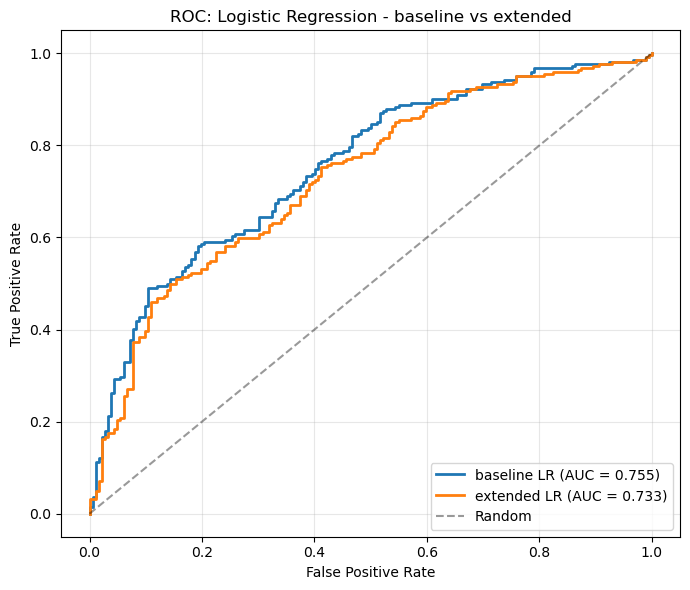

In [4]:
plt.figure(figsize=(7, 6))
for name, df, color in [('baseline LR', pred_base, 'tab:blue'),
                         ('extended LR', pred_ext, 'tab:orange')]:
    fpr, tpr, _ = roc_curve(df['label'], df['probability'])
    auc = roc_auc_score(df['label'], df['probability'])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC: Logistic Regression - baseline vs extended')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_extended_roc.png', dpi=150)
plt.show()

## 4. Confusion matrices side by side

Compares the structure of errors (false positives vs false negatives) between the two pipelines.

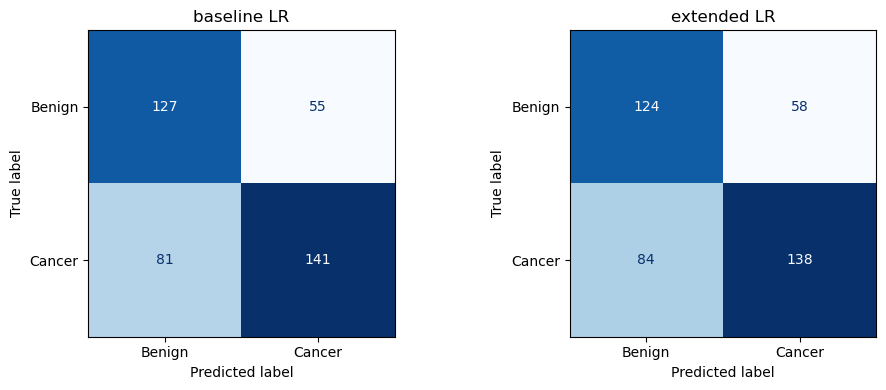

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, df) in zip(axes, [('baseline LR', pred_base), ('extended LR', pred_ext)]):
    cm = confusion_matrix(df['label'], df['predicted'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Cancer'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_extended_cm.png', dpi=150)
plt.show()

## 5. Calibration overlay

Are the predicted probabilities still well-calibrated under hair removal?

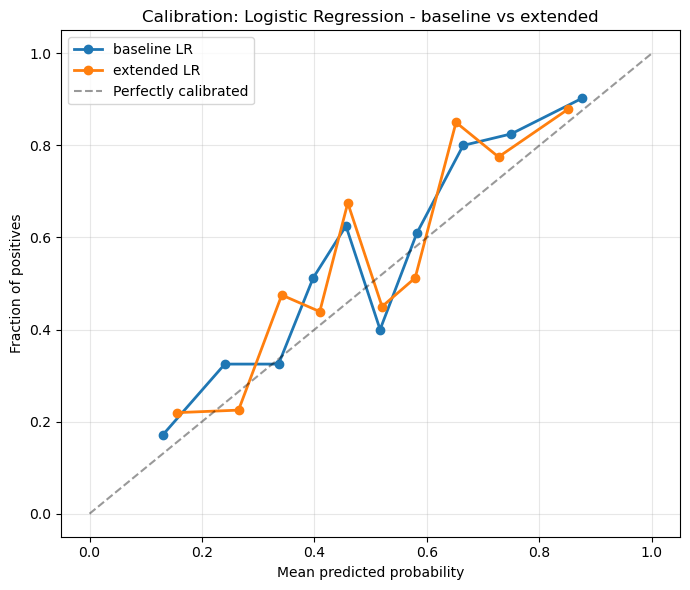

In [6]:
plt.figure(figsize=(7, 6))
for name, df, color in [('baseline LR', pred_base, 'tab:blue'),
                         ('extended LR', pred_ext, 'tab:orange')]:
    frac_pos, mean_pred = calibration_curve(df['label'], df['probability'], n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', color=color, lw=2, label=name)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration: Logistic Regression - baseline vs extended')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_extended_cal.png', dpi=150)
plt.show()

## 6. Bootstrap 95% confidence intervals for AUC

How stable is each test-set AUC under resampling? Overlapping intervals mean we cannot statistically distinguish the two pipelines on the held-out test set.

In [7]:
def bootstrap_auc_ci(df, n_iter=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = df['label'].values
    y_prob = df['probability'].values
    n = len(df)
    aucs = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    aucs = np.array(aucs)
    return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

base_mean, base_lo, base_hi = bootstrap_auc_ci(pred_base)
ext_mean,  ext_lo,  ext_hi  = bootstrap_auc_ci(pred_ext)

ci_df = pd.DataFrame({
    'AUC (mean)': [base_mean, ext_mean],
    'CI lower':   [base_lo, ext_lo],
    'CI upper':   [base_hi, ext_hi],
    'CI width':   [base_hi - base_lo, ext_hi - ext_lo],
}, index=['baseline LR', 'extended LR'])
ci_df.round(4)

,AUC (mean),CI lower,CI upper,CI width
baseline LR,0.7545,0.7063,0.7975,0.0912
extended LR,0.7322,0.6828,0.7774,0.0946


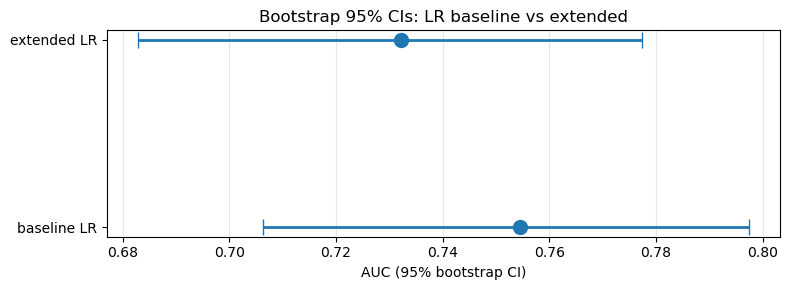

In [8]:
# Visualise CIs as error bars
fig, ax = plt.subplots(figsize=(8, 3))
y_pos = np.arange(len(ci_df))
ax.errorbar(
    ci_df['AUC (mean)'], y_pos,
    xerr=[ci_df['AUC (mean)'] - ci_df['CI lower'],
          ci_df['CI upper'] - ci_df['AUC (mean)']],
    fmt='o', capsize=6, markersize=10, lw=2,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(ci_df.index)
ax.set_xlabel('AUC (95% bootstrap CI)')
ax.set_title('Bootstrap 95% CIs: LR baseline vs extended')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_extended_ci.png', dpi=150)
plt.show()

## 7. Per-fold paired comparison + statistical test

The five CV folds are paired (same patient subsets in baseline and extended). We plot each fold as a connected pair, and run paired Wilcoxon + paired t-test on the per-fold differences.

**No Bonferroni correction is needed here** because there is only one comparison.

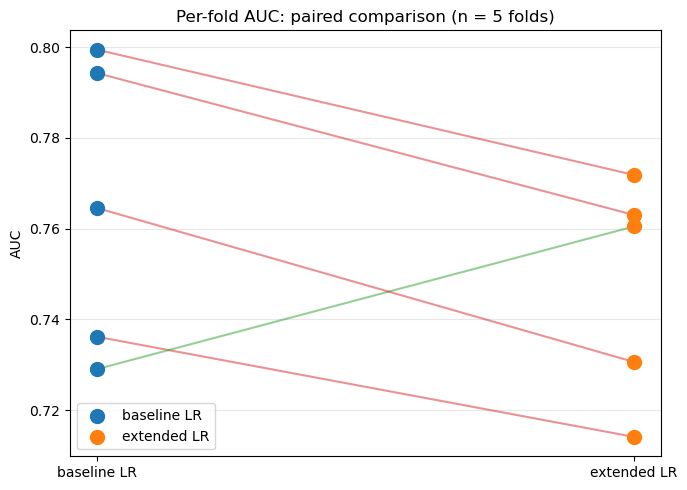

In [9]:
base_aucs = cv_base['auc'].values
ext_aucs  = cv_ext['auc'].values
diff      = ext_aucs - base_aucs

# Paired dot plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter([0]*len(base_aucs), base_aucs, color='tab:blue',   s=100, zorder=3, label='baseline LR')
ax.scatter([1]*len(ext_aucs),  ext_aucs,  color='tab:orange', s=100, zorder=3, label='extended LR')
for i in range(len(base_aucs)):
    col = 'tab:red' if ext_aucs[i] < base_aucs[i] else 'tab:green'
    ax.plot([0, 1], [base_aucs[i], ext_aucs[i]], color=col, alpha=0.5, lw=1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['baseline LR', 'extended LR'])
ax.set_ylabel('AUC')
ax.set_title(f'Per-fold AUC: paired comparison (n = {len(base_aucs)} folds)')
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_extended_paired.png', dpi=150)
plt.show()

In [10]:
# Paired statistical tests
try:
    _, w_p = wilcoxon(diff)
except ValueError:
    w_p = np.nan
_, t_p = ttest_rel(ext_aucs, base_aucs)

print(f'baseline LR per-fold AUC:  {[round(a, 4) for a in base_aucs]}  (mean = {base_aucs.mean():.4f})')
print(f'extended LR per-fold AUC:  {[round(a, 4) for a in ext_aucs]}  (mean = {ext_aucs.mean():.4f})')
print(f'Per-fold diffs (ext-base): {[round(d, 4) for d in diff]}')
print(f'Mean diff (ext - base):    {diff.mean():+.4f}')
print()
print(f'Paired Wilcoxon p:         {w_p:.4f}')
print(f'Paired t-test p:           {t_p:.4f}')
print()
print('Interpretation:')
print('- With n=5 folds, Wilcoxon cannot reach p < 0.05 (minimum p = 0.0625).')
print('- The paired t-test is the more sensitive test here.')
print('- No Bonferroni correction applied: only one comparison.')

baseline LR per-fold AUC:  [np.float64(0.7994), np.float64(0.7943), np.float64(0.7362), np.float64(0.7291), np.float64(0.7645)]  (mean = 0.7647)
extended LR per-fold AUC:  [np.float64(0.7718), np.float64(0.763), np.float64(0.7141), np.float64(0.7605), np.float64(0.7306)]  (mean = 0.7480)
Per-fold diffs (ext-base): [np.float64(-0.0276), np.float64(-0.0312), np.float64(-0.0221), np.float64(0.0314), np.float64(-0.0339)]
Mean diff (ext - base):    -0.0167

Paired Wilcoxon p:         0.4375
Paired t-test p:           0.2430

Interpretation:
- With n=5 folds, Wilcoxon cannot reach p < 0.05 (minimum p = 0.0625).
- The paired t-test is the more sensitive test here.
- No Bonferroni correction applied: only one comparison.


## 8. Conclusion

Fill in the numbers from the cells above and write 2-3 sentences for the report.

**Template** (replace numbers with what the cells produce):

> Logistic Regression was compared on the baseline and extended feature sets. On the held-out test set, baseline LR achieved AUC = X with bootstrap 95% CI [a, b], while extended LR achieved AUC = Y with CI [c, d]. The two confidence intervals overlap substantially. Across the five CV folds the paired t-test yielded p = Z (Wilcoxon p = 0.0625, the floor at n = 5), and the mean AUC difference (extended - baseline) was D. Since hair removal did not improve any metric and slightly hurt mean AUC, the final model is the baseline-trained Logistic Regression. The mechanism behind this small drop is documented in `feature_comparison.ipynb`: inpainting alters HSV colour features, especially the saturation channel, without producing useful information for the classifier.